# Ciência de Dados Geoespaciais - Modelagem

**Maj Diego - 2° Semestre / 2026**

**Objetivos**

1. Treinar um modelo de classificação em áreas de classes conhecidas em uma imagem Sentinel-1;
2. Testar e avaliar o modelo;
3. Inferir as classes de todos os pixels (classificar) da imagem Sentinel-1 dentro da região de interesse:

wkt_geom	| inom	| mi
---| --- | ---
Polygon ((-55 -2.5, -54.5 -2.5, -54.5 -2.0, -55 -2.0, -55 -2.5)) |	SA-21-Z-B-II	 | 0474

![alt text](media/imgs/segmentacao_radar.png)

## Softwares de classificação

**Scikit-Learn**: Ferramenta simples e eficiente para análise preditiva de dados em Python. Acessível a todos e reutilizável em vários contextos. Construído sobre NumPy, SciPy e matplotlib.
Código aberto, comercialmente utilizável - Licença BSD.

## Download da amostra pronta para análise

In [2]:
import os

if os.path.exists("S1_mosaic.zip"):
    print("O arquivo 'S1_mosaic.zip' já existe.")
else:
    # https://drive.google.com/file/d/1HqCf3UVHxQoIahhIVTlUAlhPmt_20P5e/view?usp=sharing
    !gdown 1HqCf3UVHxQoIahhIVTlUAlhPmt_20P5e

O arquivo 'S1_mosaic.zip' já existe.


In [3]:
if os.path.exists("S1_mosaic"):
    print("O diretório 'S1_mosaic' já existe.")
else:
    # Power Shell
    # !Remove-Item "S1_mosaic" -Recurse -Force
    # !tar -xvf S1_mosaic.zip

    # CMD
    !rmdir /s /q "S1_mosaic"
    !tar -xvf S1_mosaic.zip

    # Linux/MacOS
    # !rm -rf S1_mosaic
    # !unzip S1_mosaic.zip

O diretório 'S1_mosaic' já existe.


In [4]:
if os.path.exists("aoi.geojson"):
    print("O arquivo 'aoi.geojson' já existe.")
else:
    # https://drive.google.com/file/d/1t4DBd2GSGRQYY6J7uKJRkgnEJYBJC7ND/view?usp=drive_link
    !gdown 1t4DBd2GSGRQYY6J7uKJRkgnEJYBJC7ND

O arquivo 'aoi.geojson' já existe.


## Dados de entrada

Para esta classificação, vamos criar um `BandSet` [36 x W X H], usando o conjunto de imagens das polarizações VH (uma por mês), VV (uma por mês) e VH/VV (uma por mês)


### Composição da divisão VH/VV

In [7]:
import rasterio
import numpy as np

vh_path = r"S1_mosaic\VH"
vv_path = r"S1_mosaic\VV"
vh_over_vv_path = r"S1_mosaic\VH_over_VV"
os.makedirs(vh_over_vv_path, exist_ok=True)

vh_file_paths = [
    os.path.join(vh_path, filename)
    for filename in os.listdir(vh_path)
    if filename.endswith(".tif")
]

for vh_file_path in vh_file_paths:
    filename = os.path.basename(vh_file_path)
    vv_file_path = os.path.join(vv_path, filename)
    output_path = os.path.join(vh_over_vv_path, filename)

    with rasterio.open(vh_file_path) as vh_src, rasterio.open(vv_file_path) as vv_src:
        if (vh_src.shape, vh_src.transform, vh_src.crs) != (vv_src.shape, vv_src.transform, vv_src.crs):
            raise ValueError(f"Grades incompatíveis para {filename}")
        vh = vh_src.read(1).astype(np.float32)
        vv = vv_src.read(1).astype(np.float32)
        ratio = np.divide(vh, vv, out=np.full_like(vh, np.nan), where=vv != 0)
        profile = vh_src.profile.copy()

    profile.update(dtype="float32", count=1, nodata=np.nan)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(ratio, 1)
    print("Criado:", output_path)


Criado: S1_mosaic\VH_over_VV\20250107.tif
Criado: S1_mosaic\VH_over_VV\20250119.tif
Criado: S1_mosaic\VH_over_VV\20250131.tif
Criado: S1_mosaic\VH_over_VV\20250212.tif
Criado: S1_mosaic\VH_over_VV\20250224.tif
Criado: S1_mosaic\VH_over_VV\20250308.tif
Criado: S1_mosaic\VH_over_VV\20250320.tif
Criado: S1_mosaic\VH_over_VV\20250401.tif
Criado: S1_mosaic\VH_over_VV\20250413.tif
Criado: S1_mosaic\VH_over_VV\20250425.tif
Criado: S1_mosaic\VH_over_VV\20250507.tif
Criado: S1_mosaic\VH_over_VV\20250519.tif
Criado: S1_mosaic\VH_over_VV\20250531.tif
Criado: S1_mosaic\VH_over_VV\20250612.tif
Criado: S1_mosaic\VH_over_VV\20250624.tif
Criado: S1_mosaic\VH_over_VV\20250706.tif
Criado: S1_mosaic\VH_over_VV\20250718.tif
Criado: S1_mosaic\VH_over_VV\20250730.tif
Criado: S1_mosaic\VH_over_VV\20250823.tif
Criado: S1_mosaic\VH_over_VV\20250904.tif
Criado: S1_mosaic\VH_over_VV\20250916.tif
Criado: S1_mosaic\VH_over_VV\20250928.tif
Criado: S1_mosaic\VH_over_VV\20251010.tif
Criado: S1_mosaic\VH_over_VV\20251

### Junção pela média de imagens do mesmo mês

In [8]:
# Exemplo de imagens que devem ser juntadas
meses = ['202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512']
jan = [f for f in os.listdir(vh_path) if f.endswith(".tif") and meses[0] in f]
jan

['20250107.tif', '20250119.tif', '20250131.tif']

Colaremos a saída com o título `aaaamm.tif` para representar uma imagem que representa a média do mês.

In [9]:
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject

vh_path = r"S1_mosaic\VH"
vv_path = r"S1_mosaic\VV"
vh_over_vv_path = r"S1_mosaic\VH_over_VV"

vh_new_path = vh_path.replace("S1_mosaic", "S1_prepared")
vv_new_path = vv_path.replace("S1_mosaic", "S1_prepared")
vh_over_vv_new_path = vh_over_vv_path.replace("S1_mosaic", "S1_prepared")

for output_dir in (vh_new_path, vv_new_path, vh_over_vv_new_path):
    os.makedirs(output_dir, exist_ok=True)

def mean_rasters(input_paths, output_path):
    if not input_paths:
        print("Sem imagens para:", output_path)
        return

    sources = [rasterio.open(input_path) for input_path in input_paths]
    try:
        reference = sources[0]
        if any(src.crs != reference.crs for src in sources[1:]):
            raise ValueError(f"CRS incompatíveis em {input_paths}")

        left = max(src.bounds.left for src in sources)
        bottom = max(src.bounds.bottom for src in sources)
        right = min(src.bounds.right for src in sources)
        top = min(src.bounds.top for src in sources)
        if left >= right or bottom >= top:
            raise ValueError(f"As imagens não possuem interseção em {input_paths}")

        xres, yres = reference.res
        width = int((right - left) // xres)
        height = int((top - bottom) // yres)
        transform = from_origin(left, top, xres, yres)

        aligned = []
        for src in sources:
            band = np.full((height, width), np.nan, dtype=np.float32)
            reproject(
                source=rasterio.band(src, 1),
                destination=band,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=transform,
                dst_crs=reference.crs,
                dst_nodata=np.nan,
                resampling=Resampling.nearest,
            )
            aligned.append(band)

        mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)
        profile = reference.profile.copy()
        profile.update(
            width=width,
            height=height,
            transform=transform,
            dtype="float32",
            count=1,
            nodata=np.nan,
        )
        with rasterio.open(output_path, "w", **profile) as dst:
            dst.write(mean_band, 1)
        print("Criado:", output_path)
    finally:
        for src in sources:
            src.close()

for mes in meses:
    for input_dir, output_dir in (
        (vh_path, vh_new_path),
        (vv_path, vv_new_path),
        (vh_over_vv_path, vh_over_vv_new_path),
    ):
        input_paths = [
            os.path.join(input_dir, filename)
            for filename in os.listdir(input_dir)
            if filename.endswith(".tif") and mes in filename
        ]
        mean_rasters(input_paths, os.path.join(output_dir, f"{mes}.tif"))


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VH\202501.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VV\202501.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VH_over_VV\202501.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VH\202502.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VV\202502.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VH_over_VV\202502.tif
Criado: S1_prepared\VH\202503.tif
Criado: S1_prepared\VV\202503.tif
Criado: S1_prepared\VH_over_VV\202503.tif
Criado: S1_prepared\VH\202504.tif
Criado: S1_prepared\VV\202504.tif
Criado: S1_prepared\VH_over_VV\202504.tif
Criado: S1_prepared\VH\202505.tif
Criado: S1_prepared\VV\202505.tif
Criado: S1_prepared\VH_over_VV\202505.tif
Criado: S1_prepared\VH\202506.tif
Criado: S1_prepared\VV\202506.tif
Criado: S1_prepared\VH_over_VV\202506.tif
Criado: S1_prepared\VH\202507.tif
Criado: S1_prepared\VV\202507.tif
Criado: S1_prepared\VH_over_VV\202507.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VH\202508.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VV\202508.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VH_over_VV\202508.tif
Criado: S1_prepared\VH\202509.tif
Criado: S1_prepared\VV\202509.tif
Criado: S1_prepared\VH_over_VV\202509.tif
Criado: S1_prepared\VH\202510.tif
Criado: S1_prepared\VV\202510.tif
Criado: S1_prepared\VH_over_VV\202510.tif
Criado: S1_prepared\VH\202511.tif
Criado: S1_prepared\VV\202511.tif
Criado: S1_prepared\VH_over_VV\202511.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VH\202512.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


Criado: S1_prepared\VV\202512.tif
Criado: S1_prepared\VH_over_VV\202512.tif


C:\Users\aluno\AppData\Local\Temp\ipykernel_10972\3419835904.py:54: RuntimeWarning: Mean of empty slice
  mean_band = np.nanmean(np.stack(aligned), axis=0).astype(np.float32)


### Juntada das 36 bandas

Um problema a ser resolvido é que utilizando o aritimética de bandas entre matrizes com tamanho por vezes diferente pode resultar em erros.

In [48]:
# Verificar o shape das imagens
import rasterio

min_shape = None
for filepath in [os.path.join(vh_new_path, f) for f in os.listdir(vh_new_path) if f.endswith(".tif")] + [os.path.join(vv_new_path, f) for f in os.listdir(vv_new_path) if f.endswith(".tif")]:
    with rasterio.open(filepath) as src:
        print(filepath, src.shape)
        if min_shape is None:
            min_shape = list(src.shape)
        if min_shape[0] > src.shape[0]:
            min_shape[0] = src.shape[0]
        if min_shape[1] > src.shape[1]:
            min_shape[1] = src.shape[1]
min_shape

S1_prepared\VH\202501.tif (5566, 5566)
S1_prepared\VH\202502.tif (5566, 5566)
S1_prepared\VH\202503.tif (5566, 5566)
S1_prepared\VH\202504.tif (5566, 5565)
S1_prepared\VH\202505.tif (5566, 5566)
S1_prepared\VH\202506.tif (5566, 5566)
S1_prepared\VH\202507.tif (5566, 5566)
S1_prepared\VH\202508.tif (5566, 5566)
S1_prepared\VH\202509.tif (5566, 5566)
S1_prepared\VH\202510.tif (5566, 5566)
S1_prepared\VH\202511.tif (5566, 5566)
S1_prepared\VH\202512.tif (5566, 5566)
S1_prepared\VV\202501.tif (5566, 5566)
S1_prepared\VV\202502.tif (5566, 5566)
S1_prepared\VV\202503.tif (5566, 5566)
S1_prepared\VV\202504.tif (5566, 5565)
S1_prepared\VV\202505.tif (5566, 5566)
S1_prepared\VV\202506.tif (5566, 5566)
S1_prepared\VV\202507.tif (5566, 5566)
S1_prepared\VV\202508.tif (5566, 5566)
S1_prepared\VV\202509.tif (5566, 5566)
S1_prepared\VV\202510.tif (5566, 5566)
S1_prepared\VV\202511.tif (5566, 5566)
S1_prepared\VV\202512.tif (5566, 5566)


[5566, 5565]

In [49]:
import numpy as np

w, h = min_shape

def get_band(filepath):
    with rasterio.open(filepath) as src:
        band = src.read(1)
    print(filepath, "Shape de entrada", band.shape, end=' --> ')
    if band.shape[0] > w:
        band = band[0:w, 0:]
    if band.shape[1] > h:
        band = band[0:, 0:h]
    print("Shape de saída", band.shape)
    return band

# Opens VHs
vhs = []
for filepath in [os.path.join(vh_new_path, f) for f in os.listdir(vh_new_path) if f.endswith(".tif")]:
    band = get_band(filepath)
    vhs.append(band)
vhs = np.array(vhs)

# Opens VVs
vvs = []
for filepath in [os.path.join(vv_new_path, f) for f in os.listdir(vv_new_path) if f.endswith(".tif")]:
    band = get_band(filepath)
    vvs.append(band)
vvs = np.array(vvs)

# Opens VH_over_VVs
vh_over_vvs = []
for filepath in [os.path.join(vh_over_vv_new_path, f) for f in os.listdir(vh_over_vv_new_path) if f.endswith(".tif")]:
    band = get_band(filepath)
    vh_over_vvs.append(band)
vh_over_vvs = np.array(vh_over_vvs)

stack = np.vstack((vhs, vvs, vh_over_vvs))
nbands = stack.shape[0]
stack.shape


S1_prepared\VH\202501.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202502.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202503.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202504.tif Shape de entrada (5566, 5565) --> Shape de saída (5566, 5565)
S1_prepared\VH\202505.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202506.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202507.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202508.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202509.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202510.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202511.tif Shape de entrada (5566, 5566) --> Shape de saída (5566, 5565)
S1_prepared\VH\202512.tif Shape 

(36, 5566, 5565)

In [50]:
# free memory
del vhs
del vvs
del vh_over_vvs

### Adição da coluna `class_id` ao arquivo das classes de amostra

In [51]:
import json
from pprint import pprint
from shapely.geometry import mapping, shape

geojson_path = "aoi.geojson"
with open(geojson_path, encoding="utf-8") as geojson_file:
    geojson_data = json.load(geojson_file)

geojson_crs = geojson_data.get("crs", {}).get("properties", {}).get("name", "não informado")
print("GeoJSON Projection:", geojson_crs)

# Converte as geometrias GeoJSON em objetos Shapely
geometries = [shape(feature["geometry"]) for feature in geojson_data["features"]]

c_p = []
for feature in geojson_data["features"]:
    properties = feature.get("properties", {})
    c_p.append((properties.get("classe"), properties.get("pixels")))
c_p = sorted(c_p, key=lambda x: x[0])
print("\nClasses e pixels:")
pprint(c_p)

class_id_map = {
    'agua': 1,
    'areainunda': 2,
    'areaurbana': 3,
    'pastagem': 4,
    'soloexposto': 5,
    'vegprim': 6,
    'vegsec': 7,
}

c_i = []
for feature, geometry in zip(geojson_data["features"], geometries):
    properties = feature.setdefault("properties", {})
    classe = properties.get("classe")
    class_id = class_id_map.get(classe, 0)
    properties["class_id"] = class_id
    feature["geometry"] = mapping(geometry)
    c_i.append((classe, class_id))

with open(geojson_path, "w", encoding="utf-8") as geojson_file:
    json.dump(geojson_data, geojson_file, ensure_ascii=False, indent=2)

c_i = sorted(c_i, key=lambda x: x[0])
print("\nClasses e IDs:")
pprint(c_i)

rotulos = sorted({classe for classe, _ in c_i})


GeoJSON Projection: urn:ogc:def:crs:OGC:1.3:CRS84

Classes e pixels:
[('agua', 33719),
 ('agua', 26882),
 ('areainunda', 87717),
 ('areainunda', 45161),
 ('areaurbana', 6807),
 ('areaurbana', 13139),
 ('pastagem', 434),
 ('pastagem', 143),
 ('soloexposto', 309),
 ('soloexposto', 5600),
 ('vegprim', 7963),
 ('vegprim', 1449),
 ('vegsec', 3902),
 ('vegsec', 558)]

Classes e IDs:
[('agua', 1),
 ('agua', 1),
 ('areainunda', 2),
 ('areainunda', 2),
 ('areaurbana', 3),
 ('areaurbana', 3),
 ('pastagem', 4),
 ('pastagem', 4),
 ('soloexposto', 5),
 ('soloexposto', 5),
 ('vegprim', 6),
 ('vegprim', 6),
 ('vegsec', 7),
 ('vegsec', 7)]


### Rasterizar o arquivo com as classes para treino e teste

In [52]:
from rasterio.features import rasterize

# Usa um TIF como referência espacial para criar a máscara
filepath = os.path.join(vh_new_path, os.listdir(vh_new_path)[0])
with rasterio.open(filepath) as src:
    print("TIF Projection:", src.crs)
    mask_transform = src.transform

# Rasteriza as geometrias usando class_id como valor de preenchimento
geometry_values = [
    (geometry, feature["properties"]["class_id"])
    for geometry, feature in zip(geometries, geojson_data["features"])
]
mask = rasterize(
    geometry_values,
    out_shape=(w, h),
    transform=mask_transform,
    fill=0,
    dtype=np.int16,
)
print("\nMáscara (classes) shape:", mask.shape)


TIF Projection: EPSG:4326

Máscara (classes) shape: (5566, 5565)


Total de pixels de treinamento: 235,573


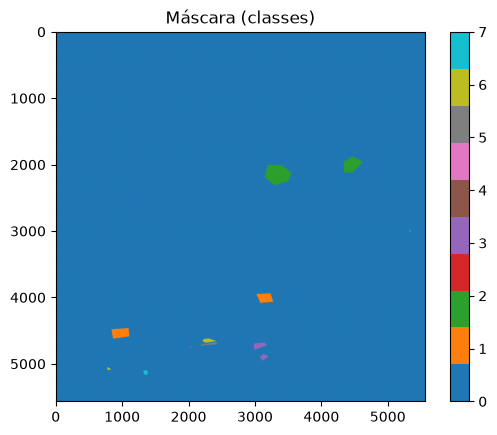

In [53]:
import matplotlib.pyplot as plt

pixels_treino = np.sum(mask > 0)
print(f"Total de pixels de treinamento: {pixels_treino:,}")

plt.imshow(mask, cmap='tab10')
plt.colorbar()
plt.title("Máscara (classes)")
plt.show()

#### Reorganizar imagens --> (36, H, W) → (H x W, 36)

In [54]:
# Transpor imagem: (36, H, W) → (H, W, 36)
img_transposta = np.permute_dims(stack, (1, 2, 0))
del stack

# Flatten: (H*W, 36) — cada linha é um pixel com 36 features
n_pixels = h * w
X_all = img_transposta.reshape(n_pixels, nbands)
del img_transposta

# Tratar NaN/Inf (pixels inválidos)
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)
X_all[X_all>3e+38] = 0.0

print("Vetor de características de cada pixel (X):", X_all.shape)

# Máscara flatten
y_all = mask.flatten()
print("Vetor de classes (Y):", y_all.shape)

Vetor de características de cada pixel (X): (30974790, 36)
Vetor de classes (Y): (30974790,)


In [55]:
# Selecionar apenas pixels com rótulo (classe > 0)
mask_valid = y_all > 0
X_treino = X_all[mask_valid]
y_treino = y_all[mask_valid]

print(f"X_treino shape: {X_treino.shape}")
print(f"Y_treino shape: {y_treino.shape}")

X_treino shape: (235573, 36)
Y_treino shape: (235573,)


#### Distribuição das classes

In [56]:
classes = np.unique(y_all)
print("Classes presentes:\n", classes, "→", 'SemClasse, ' + ', '.join(rotulos))
print(f"\nDistribuição das classes:")
for c in classes:
    n = np.sum(y_all == c)
    print(f"      Classe {c}: {n:,} pixels")

Classes presentes:
 [0 1 2 3 4 5 6 7] → SemClasse, agua, areainunda, areaurbana, pastagem, soloexposto, vegprim, vegsec

Distribuição das classes:
      Classe 0: 30,739,217 pixels
      Classe 1: 61,060 pixels
      Classe 2: 133,880 pixels
      Classe 3: 20,101 pixels
      Classe 4: 581 pixels
      Classe 5: 5,953 pixels
      Classe 6: 9,506 pixels
      Classe 7: 4,492 pixels


#### Normalização do vetor de características

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)

### Divisão treino e teste

In [58]:
from sklearn.model_selection import train_test_split

X_tr, X_test, y_tr, y_test = train_test_split(
    X_treino_scaled, y_treino,
    test_size=0.2,
    random_state=13, # arbitrário, usado para replicabilidade
    stratify=y_treino
)
print(f"Treino: {X_tr.shape[0]:,} | Teste: {X_test.shape[0]:,}")

Treino: 188,458 | Teste: 47,115


## Modelo

### Floresta aleatória

**scikit-learn RandomForestClassifier docs**: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [59]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,       # Número de árvores.
    max_depth=None,         # Sem limite de profundidade.
    min_samples_split=5,
    min_samples_leaf=2,     # Mínimo de amostras necessário para estar em um nó folha.
    max_features='sqrt',    # √n_features = The number of features to consider when looking for the best split.
    class_weight='balanced',# {"balanced", "balanced_subsample"}, dict or list of dicts, default=None. 
                            # Pesos associados a classes na forma {class_label: weight}. 
                            # "None", todas as classes tem peso um.
                            # "balanced" usa os valores de y para ajustar automaticamente pesos inversamente proporcionais 
                            # às frequências de classe nos dados de entrada como n_samples / (n_classes * np.bincount(y)).
    n_jobs=-1,              # Usar todos os núcleos da CPU
    random_state=13,
    # verbose=1
)

## Treino

In [60]:
clf.fit(X_tr, y_tr)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",13
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

### Visualização de cada árvore de decisão na floresta

In [61]:
# Plot first tree of the Randomforest (index 0)
# https://stackoverflow.com/questions/40155128/plot-trees-for-a-random-forest-in-python-with-scikit-learn

from sklearn import tree

arvore_id = 0

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (14,14), dpi=800)
tree.plot_tree(clf.estimators_[arvore_id],
               feature_names = range(1, nbands+1), 
               class_names = rotulos,
               filled = True)
fig.savefig('rf_individualtree.png')


## Teste e avaliação


Avaliando o modelo...

Relatório de Classificação:
              precision    recall  f1-score   support

    Classe 1       1.00      1.00      1.00     12212
    Classe 2       1.00      1.00      1.00     26776
    Classe 3       0.99      0.97      0.98      4020
    Classe 4       1.00      0.95      0.97       116
    Classe 5       1.00      1.00      1.00      1191
    Classe 6       0.94      0.99      0.96      1901
    Classe 7       0.98      1.00      0.99       899

    accuracy                           1.00     47115
   macro avg       0.99      0.99      0.99     47115
weighted avg       1.00      1.00      1.00     47115

Matriz de confusão salva em: matriz_confusao.png


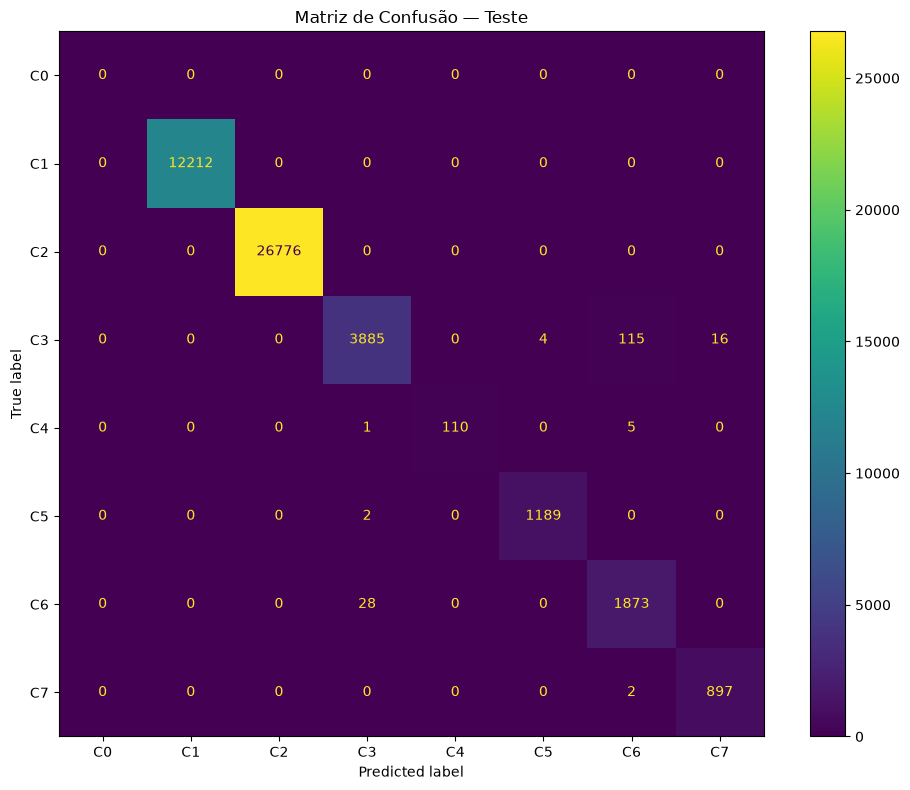

In [62]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nAvaliando o modelo...")
y_pred = clf.predict(X_test)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=[f"Classe {c}" for c in classes[1:]]))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=classes)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"C{c}" for c in classes])
disp.plot(ax=ax, colorbar=True)
plt.title("Matriz de Confusão — Teste")
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=150)
print("Matriz de confusão salva em: matriz_confusao.png")

> As classes 3 e 6 (areaurbana e vegprim) possuem a maior parte dos erros.

> $acuracia = \frac{acertos}{total}$, está enviesado pois houve muitos acertos nas classes 1 e 2 que possuem a maior parte dos dados.

### Verificação de qual banda foi mais importante para melhorar as métricas

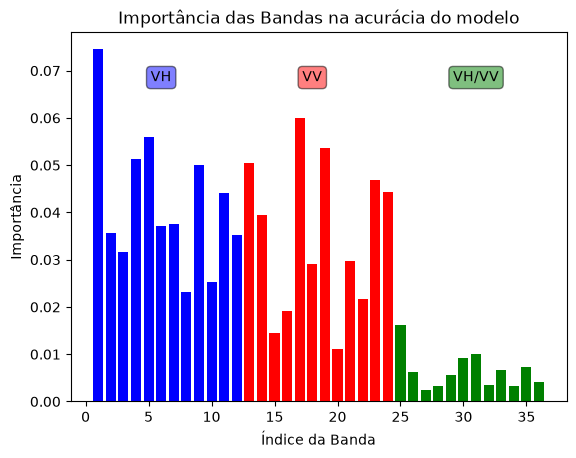

In [63]:
importances = clf.feature_importances_

# for idx, imp in enumerate(importances):
#     print(f"Banda {idx+1}: {imp:.4f}")

# Define colors: first 12 bars in blue, 13:24 in red,rest in green
colors = ['blue'] * 12 + ['red'] * 12 + ['green'] * (len(importances) - 24)

plt.bar(range(1, len(importances) + 1), importances, color=colors)
plt.xlabel("Índice da Banda")
plt.ylabel("Importância")
plt.title("Importância das Bandas na acurácia do modelo")
plt.annotate('VH', 
            xy=(6, importances[5]),  # Top of the 6th bar (0-based index)
            xytext=(6, importances[5] + 0.03),  # Slightly above the bar
            ha='center', va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="blue", alpha=0.5, edgecolor="black"))
plt.annotate('VV', 
            xy=(18, importances[17]),  # Top of the 18th bar (0-based index)
            xytext=(18, importances[5] + 0.03),  # Slightly above the bar
            ha='center', va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.5, edgecolor="black"))
plt.annotate('VH/VV', 
            xy=(31, importances[19]),  # Top of the 18th bar (0-based index)
            xytext=(31, importances[5] + 0.03),  # Slightly above the bar
            ha='center', va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="green", alpha=0.5, edgecolor="black"))
plt.show()
plt.show()

> A composição VH/VV contribuiu menos para a acurácia do modelo.

## Inferência

In [64]:
print("Classificando imagem completa...")

# Normalizar toda a imagem com o mesmo scaler
X_all_scaled = scaler.transform(X_all)

# Classificar em chunks para evitar estouro de memória
CHUNK_SIZE = 500_000  # pixels por vez
y_classificado = np.zeros(n_pixels, dtype=np.uint8)

for i in range(0, n_pixels, CHUNK_SIZE):
    chunk = X_all_scaled[i : i + CHUNK_SIZE]
    y_classificado[i : i + CHUNK_SIZE] = clf.predict(chunk)
    if (i // CHUNK_SIZE) % 5 == 0:
        pct = 100 * i / n_pixels
        print(f"   Progresso: {pct:.1f}%")


Classificando imagem completa...
   Progresso: 0.0%
   Progresso: 8.1%
   Progresso: 16.1%
   Progresso: 24.2%
   Progresso: 32.3%
   Progresso: 40.4%
   Progresso: 48.4%
   Progresso: 56.5%
   Progresso: 64.6%
   Progresso: 72.6%
   Progresso: 80.7%
   Progresso: 88.8%
   Progresso: 96.9%


#### Visualizar resultado

Visualização salva em: resultado_classificacao.png


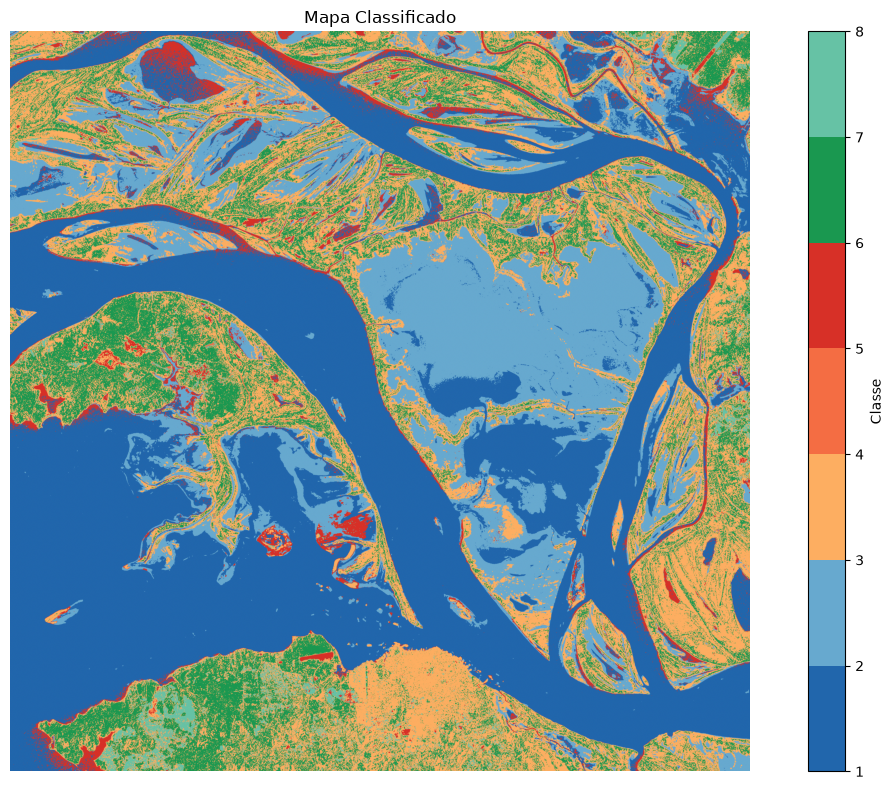

In [72]:
import matplotlib.colors as mcolors

# cmap = plt.get_cmap('tab10', len(classes) + 1)

# or build custom colormap
class_colors = {
    'agua': '#2166ac',
    'areainunda': '#67a9cf',
    'areaurbana': '#fdae61',
    'pastagem': '#f46d43',
    'soloexposto': '#d73027',
    'vegprim': '#1a9850',
    'vegsec': '#66c2a5',
}
colors = [class_colors[c] for c in rotulos]
cmap = mcolors.ListedColormap(colors, name='my_classes')

fig, axes = plt.subplots(1, 1, figsize=(12, 8))

# Mapa classificado
resultado = y_classificado.reshape(w, h)
im = axes.imshow(resultado, cmap=cmap, vmin=1, vmax=len(classes))
axes.set_title("Mapa Classificado")
axes.axis('off')
plt.colorbar(im, ax=axes, label='Classe')

plt.tight_layout()
plt.savefig("resultado_classificacao.png", dpi=80, bbox_inches='tight')
print("Visualização salva em: resultado_classificacao.png")


> Em ciência da computação, **garbage in, garbage out* (GIGO) é o conceito de que informações ou entradas falhas, tendenciosas ou de baixa qualidade ("lixo") produzem um resultado de qualidade semelhante ("lixo"). O ditado aponta para a necessidade de melhorar a qualidade dos dados.

> "Sem dados de qualidade, até as análises mais sofisticadas e os algoritmos mais avançados falharão. A base para qualquer sucesso em IA é garantir que os dados sejam limpos, consistentes e precisos."

### Salvar

In [68]:
## Salvar modelo treinado
import joblib

joblib.dump(clf,    "modelo_rf.pkl")
joblib.dump(scaler, "scaler.pkl")

## Salvar a inferência completa
with rasterio.open("./S1_prepared/VH/202501.tif") as src:
    profile    = src.profile.copy()

profile_out = profile.copy()
profile_out.update({
    'count': 1,
    'dtype': 'uint8',
    'compress': 'lzw',
    'nodata': 0
})

with rasterio.open("infer_RF.tif", 'w', **profile_out) as dst:
    dst.write(resultado[np.newaxis, :, :])


## Prática

- Retirar as 12 bandas VV/VH e substituir por Sentinel-2
- Melhorar a aquisição das classes para treino
- Acabamento artístico com abertura e fechamento

## Referências:

[Scikit-Learn User Guide](https://scikit-learn.org/stable/user_guide.html)

[Scikit-Learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html)

[Fundamentals of Digital Image Processing: A Practical Approach with Examples in Matlab](https://www.fundipbook.com/)

[Scikit-Image Morphological operations](https://scikit-image.org/skimage-tutorials/lectures/3_morphological_operations.html)